## 0. Setup for the Notebook: 

This workbook will start out by producing radiation from a single region, then we will move onto considering emission from many regions, understanding what different methods are for interpreting SEDs. 

In [1]:
from pathlib import Path
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from bhjet import BHJet, BLJet, RadiationZone

OBSERVING_BANDS_HZ = {
    'radio': 2.4e9, 'sub-mm': 2.4e11, 'infrared': 2.4e13,
    'optical/UV': 4.8e15, 'X-ray': 2.4e18, 'gamma-ray': 2.4e22,
}

def add_observing_band_labels(ax):
    for label, frequency_hz in OBSERVING_BANDS_HZ.items():
        ax.text(frequency_hz, 1.02, label, transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=9, clip_on=False)

def find_repository_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'tutorials' / 'tutorial_data').is_dir():
            return candidate

repository_root = find_repository_root()

def load_m87_data(path):
    raw = Table.read(path, format='ascii.no_header')
    data = Table()
    data['frequency_hz'] = np.asarray(raw['col3'], dtype=float) * u.Hz
    # The M87 flux-density column is Jy, so we're gonna use Astropy to convert it to mJy.
    data['flux_mjy'] = (np.asarray(raw['col4'], dtype=float) * u.Jy).to(u.mJy)
    data['flux_mjy_error'] = (np.asarray(raw['col5'], dtype=float) * u.Jy).to(u.mJy)
    return data

def load_gx3394_data(path):
    raw = Table.read(path, format='ascii.no_header')
    data = Table()
    frequency_min = np.asarray(raw['col1'], dtype=float) * u.Hz
    frequency_max = np.asarray(raw['col2'], dtype=float) * u.Hz
    # Using the middle of each supplied frequency range, because this is how the data came to us. 
    data['frequency_hz'] = np.sqrt(frequency_min * frequency_max)
    data['flux_mjy'] = np.asarray(raw['col3'], dtype=float) * u.mJy
    data['flux_mjy_error'] = np.asarray(raw['col4'], dtype=float) * u.mJy
    return data

DATA_LOADERS = {
    'M87': load_m87_data,
    'GX 339-4': load_gx3394_data,
}

## 1. Creating a single emission region

We're going to start by reproducing radiation from a "blob" of plasma. However, we still need to set some conditions for the source, so we'll start with parameters that correspond to M87. Later in the notebook we will compare the SEDs generated here with observations of M87 from the 2017 EHT multi-wavelength campaign. 

In [2]:
# --- Choose the source and set its physical properties (as provided in the notebook) ---
SOURCE_NAME = 'M87'  # Choose 'M87' or 'GX 339-4'
DISTANCE_KPC = 29400
REDSHIFT = 0.007465
VIEWING_ANGLE_DEG = 66.0
BLACK_HOLE_MASS_SOLAR = 5e8

data_directory = repository_root / 'tutorials' / 'tutorial_data'
SOURCE_FILES = {'M87': 'M87_MWL.txt', 'GX 339-4': 'gx3394_MWL.txt'}
data_file = data_directory / SOURCE_FILES[SOURCE_NAME]

In [3]:
# We first need an energy grid over which to calculate the radiation: 
energy_eV = np.geomspace(1e-9, 1e11, 200) 


# This dictionary sets up the conditions within our blob; 
SINGLE_ZONE_PARAMETERS = {
    'magnetic_field': 0.2,                 # uniform field [G]
    'radius': 1e16,                        # blob size [cm]
    'height': 1e16,                        # blob height [cm]
    'geometry': 'sphere',
    'bulk_momentum': 2.0,
    'electron_number_density': 1e3,        # cm^-3
    'electron_temperature': 900.0,         # keV
    'fraction_nonthermal_electrons': 0.1,
    'factor_break_electrons': 0.1,
    'factor_max_energy_electrons': 1e-7,
    'index_injected_electrons': 1.8,
}


#this function is here to make it easier to re-calculate the single zone spectrum: 
def calculate_single_zone_sed(parameters, energy_grid_eV=energy_eV):
    single_zone = RadiationZone(
        distance=DISTANCE_KPC, redshift=REDSHIFT, theta_obs=VIEWING_ANGLE_DEG,
        include_counterjet=True, compton_threshold=1e-5,
        **parameters,
    )
    single_zone.compute_particles()
    energy_grid = energy_grid_eV * u.eV
    single_zone.compute_radiation(energy_grid.to_value(u.erg).tolist())

    model_energy = np.asarray(
        single_zone.get_observed_photon_energy_grid_total(), dtype=float
    ) * u.erg
    model_flux = np.asarray(
        single_zone.get_observed_photon_flux_total(), dtype=float
    ) / (u.cm**2 * u.s)
    model_sed = (model_energy * model_flux).to(u.erg / (u.cm**2 * u.s))
    return single_zone, model_energy.to(u.eV), model_sed

def get_single_zone_component_seds(single_zone):
    synchrotron_energy = np.asarray(
        single_zone.get_observed_photon_energy_grid_electron_cyclosyn(), dtype=float
    ) * u.erg
    synchrotron_flux = np.asarray(
        single_zone.get_observed_photon_flux_electron_cyclosyn(), dtype=float
    ) / (u.cm**2 * u.s)
    ssc_energy = np.asarray(
        single_zone.get_observed_photon_energy_grid_electron_compton(), dtype=float
    ) * u.erg
    ssc_flux = np.asarray(
        single_zone.get_observed_photon_flux_electron_compton(), dtype=float
    ) / (u.cm**2 * u.s)
    return {
        'synchrotron': (synchrotron_energy.to(u.eV), (synchrotron_energy * synchrotron_flux).to(u.erg / (u.cm**2 * u.s))),
        'ssc': (ssc_energy.to(u.eV), (ssc_energy * ssc_flux).to(u.erg / (u.cm**2 * u.s))),
    }

single_zone, single_zone_energy_eV, single_zone_sed = calculate_single_zone_sed(
    SINGLE_ZONE_PARAMETERS
)
single_zone_components = get_single_zone_component_seds(single_zone)

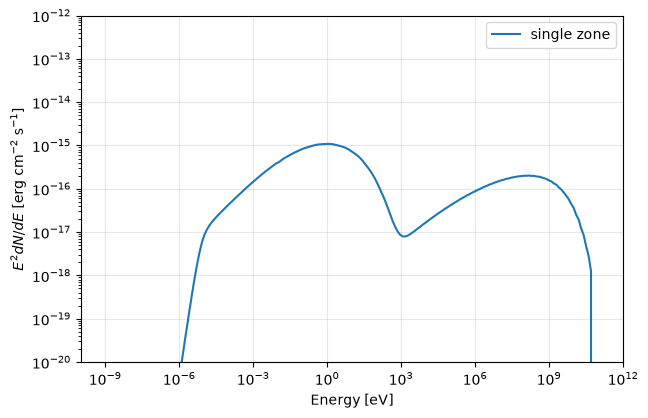

In [4]:
# Plotting our calculated spectrum: 
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(single_zone_energy_eV.to_value(u.Hz, equivalencies=u.spectral()),
          single_zone_sed.to_value(u.erg / (u.cm**2 * u.s)),
          c='k', label='single-zone total')
for label, colour in [('synchrotron', 'tab:blue'), ('ssc', 'tab:red')]:
    component_energy, component_sed = single_zone_components[label]
    ax.loglog(component_energy.to_value(u.Hz, equivalencies=u.spectral()),
              component_sed.to_value(u.erg / (u.cm**2 * u.s)),
              c=colour, ls='--', label=label.upper() if label == 'ssc' else label)
ax.set(xlabel='Frequency [Hz]', ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]')
ax.grid(alpha=0.3)
add_observing_band_labels(ax)
ax.legend()
plt.ylim(1e-20, 1e-12)
plt.show()

## 2. Now, let's compare it to observations. 

We'll load the observations for M87, change a few of the parameters, re-run the code and try to get it to match the observations.

In [5]:
data = DATA_LOADERS[SOURCE_NAME](data_file)
#loading and setting the units via astropy so we know what we're working with!
data_frequency = data['frequency_hz'].quantity
data_flux_density = data['flux_mjy'].quantity
data_flux_density_error = data['flux_mjy_error'].quantity
data_energy = data_frequency.to(u.eV, equivalencies=u.spectral())
data_sed = (data_frequency * data_flux_density).to('erg cm-2 s-1')
data_sed_error = (data_frequency * data_flux_density_error).to('erg cm-2 s-1')

#### Plotting the data and the model together: 

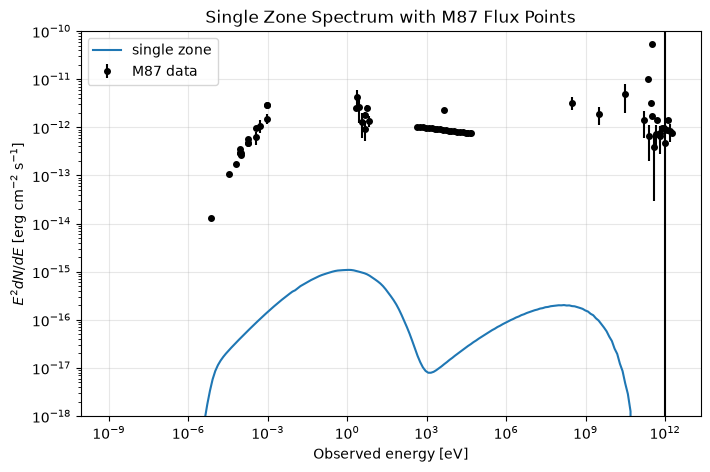

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

#plotting the data: 
ax.errorbar(data_frequency.to_value(u.Hz), data_sed.value, yerr=data_sed_error.value, fmt='o', ms=4,
            color='black', label=f'{SOURCE_NAME} data')

ax.loglog(single_zone_energy_eV.to_value(u.Hz, equivalencies=u.spectral()),
          single_zone_sed.to_value(u.erg / (u.cm**2 * u.s)),
          c='k', label='single-zone total')
for label, colour in [('synchrotron', 'tab:blue'), ('ssc', 'tab:red')]:
    component_energy, component_sed = single_zone_components[label]
    ax.loglog(component_energy.to_value(u.Hz, equivalencies=u.spectral()),
              component_sed.to_value(u.erg / (u.cm**2 * u.s)),
              c=colour, ls='--', label=label.upper() if label == 'ssc' else label)

ax.set(xlabel='Observed frequency [Hz]', ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]',
       title=f'Single Zone Spectrum with {SOURCE_NAME} Flux Points')

ax.set_ylim(1e-18, 1e-10)
ax.grid(alpha=0.3)
add_observing_band_labels(ax)
ax.legend();

## 2a. Modify the parameters here and match the M87 observations. 

The dictionary below (Single_Zone_Fit_Parameters) lists the typical free parameters that we would change while using the model. You'll carry out a simple, by-hand exploration of the parameter space; first change one of the parameters below, then plot.

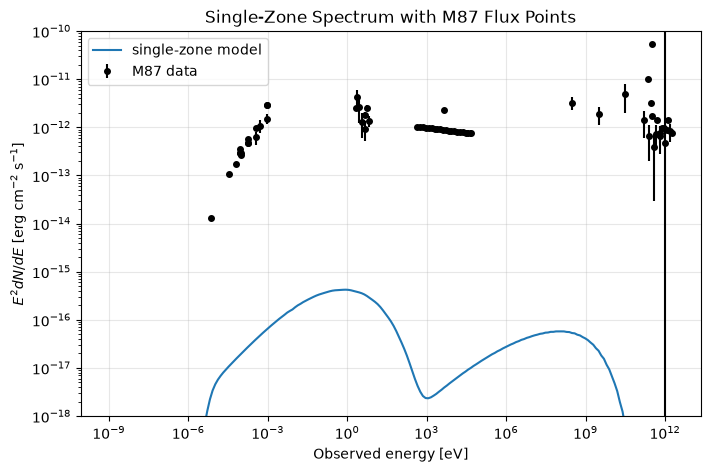

In [7]:
# Edit the values below, re-run this cell, and compare the new curve with the observations we loaded: 
SINGLE_ZONE_FIT_PARAMETERS = SINGLE_ZONE_PARAMETERS.copy()
SINGLE_ZONE_FIT_PARAMETERS.update({
    'magnetic_field': 0.2,
    'radius': 1e16,
    'bulk_momentum': 3.0,
    'electron_number_density': 1e3,
    'electron_temperature': 900.0,
    'fraction_nonthermal_electrons': 0.1,
    'factor_max_energy_electrons': 1e-7,
    'index_injected_electrons': 1.8,
})

fit_single_zone, fit_single_zone_energy_eV, fit_single_zone_sed = (calculate_single_zone_sed(SINGLE_ZONE_FIT_PARAMETERS))
fit_single_zone_components = get_single_zone_component_seds(fit_single_zone)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(data_frequency.to_value(u.Hz), data_sed.value, yerr=data_sed_error.value,
            fmt='o', ms=4, color='black', label=f'{SOURCE_NAME} data')

ax.loglog(fit_single_zone_energy_eV.to_value(u.Hz, equivalencies=u.spectral()),
          fit_single_zone_sed.to_value(u.erg / (u.cm**2 * u.s)),
          c='k', label='single-zone total')
for label, colour in [('synchrotron', 'tab:blue'), ('ssc', 'tab:red')]:
    component_energy, component_sed = fit_single_zone_components[label]
    ax.loglog(component_energy.to_value(u.Hz, equivalencies=u.spectral()),
              component_sed.to_value(u.erg / (u.cm**2 * u.s)),
              c=colour, ls='--', label=label.upper() if label == 'ssc' else label)

ax.set(xlabel='Observed frequency [Hz]',
       ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]',
       title=f'Single-Zone Spectrum with {SOURCE_NAME} Flux Points')
ax.set_ylim(1e-18, 1e-10)
ax.grid(alpha=0.3)
add_observing_band_labels(ax)
ax.legend();

## 3. Build a multi-zone BHJet model

We're going to now combine many individual radiation zone objects, and essentially use all those zones within an elongated jet profile. This is done with`BLJet`, which calculates how the jet dynamics change with distance from the black hole. `BHJet` then makes a `RadiationZone` for each part of that flow, instead of what we did by hand above, and calculates the emission from each zone.

In [25]:
MULTI_ZONE_PARAMETERS = {
    'jet_power_eddington': 2e-4,
    'r_initial': 9.0,
    'z_end_of_acceleration': 100.0,
    'z_dissipation': 100.0,
    'sigma_final': 0.1,
    'gamma_final': 2.1,
    'electron_temperature_jet_base': 500.0,
    'fraction_nonthermal_electrons': 0.5,
    'factor_break_electrons': 0.1,
    'factor_max_energy_electrons': 8e-9,
    'index_injected_electrons': 1.75,
    'plasma_beta_jet_base': 0.02, 
    'dlgz': 0.1, 
}

#very similar setup to what we did with the single zone run before
def calculate_multi_zone_sed(parameters, energy_grid_eV=energy_eV):
    dynamics = BLJet(
        mass_bh=BLACK_HOLE_MASS_SOLAR,
        z_jet_launching=2.0, z_max_calculation=1e6,
        gamma_acceleration_exponent=0.2, opening_angle_constant=0.15,
        fraction_nonthermal_protons=0.1, factor_break_protons=1.0,
        factor_max_energy_protons=1.0, index_injected_protons=2.0,
        verbosity_level=0, **parameters,
    )
    jet = BHJet(
        theta_obs=VIEWING_ANGLE_DEG, distance=DISTANCE_KPC, redshift=REDSHIFT,
        include_counterjet=True, compton_threshold=1e-5,
        profile_time=False, verbosity_level=0,
    )
    jet.init_jet_dynamics(dynamics)
    energy_grid = energy_grid_eV * u.eV
    jet.compute_full_jet(photon_energy_grid=energy_grid.to_value(u.erg).tolist())
    model_flux = np.asarray(
        jet.get_observed_photon_flux_total(), dtype=float
    ) / (u.cm**2 * u.s)
    model_sed = (energy_grid.to(u.erg) * model_flux).to(u.erg / (u.cm**2 * u.s))
    return dynamics, jet, model_sed

dynamics, multi_zone_jet, multi_zone_sed = calculate_multi_zone_sed(MULTI_ZONE_PARAMETERS)

## 3a. Compare BHJet to the observed SED 

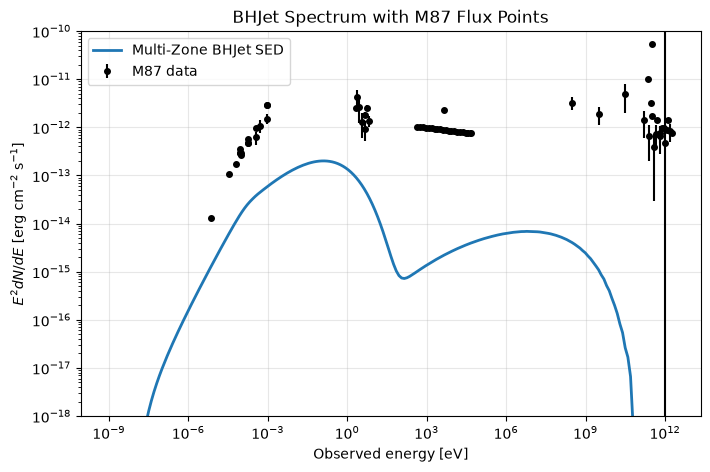

In [42]:
FIT_PARAMETERS = MULTI_ZONE_PARAMETERS.copy()
FIT_PARAMETERS.update({
    'jet_power_eddington': 2e-3,
    'z_dissipation': 100.0,
    'electron_temperature_jet_base': 500.0,
    'factor_max_energy_electrons': 8e-9,
    'index_injected_electrons': 1.75,
    'z_end_of_acceleration': 1e5
})

fit_dynamics, fit_jet, fit_sed = calculate_multi_zone_sed(FIT_PARAMETERS)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(data_frequency.to_value(u.Hz), data_sed.value, yerr=data_sed_error.value, fmt='o', ms=4,
            color='black', label=f'{SOURCE_NAME} data')

ax.loglog((energy_eV * u.eV).to_value(u.Hz, equivalencies=u.spectral()),
          multi_zone_sed.to_value(u.erg / (u.cm**2 * u.s)),
          lw=2, label='Multi-Zone BHJet SED')

ax.set(xlabel='Observed frequency [Hz]', ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]',
       title=f'BHJet Spectrum with {SOURCE_NAME} Flux Points')
ax.set_ylim(1e-18, 1e-10)
ax.grid(alpha=0.3)
add_observing_band_labels(ax)
ax.legend();

In [ ]:
#make a cell to change parameters and run code and plot all together, so they can try to match observations with mz 

## 5. Compare the one-zone and multi-zone spectra

Now, we're going to compare what the single zone and multi-zone SEDs predict; the cell below is the same as the parameter exploration cells you used previously, now you'll change both, and see how they compare on the same plot. 

In [ ]:
FIT_PARAMETERS = MULTI_ZONE_PARAMETERS.copy()
FIT_PARAMETERS.update({
    'jet_power_eddington': 2e-3, #bounds: 1e-5, 1e-1
    'z_dissipation': 100.0,
    'electron_temperature_jet_base': 500.0,
    'factor_max_energy_electrons': 8e-9,
    'index_injected_electrons': 1.75,
    'z_end_of_acceleration': 1e4
})

fit_dynamics, fit_jet, fit_sed = calculate_multi_zone_sed(FIT_PARAMETERS)

SINGLE_ZONE_FIT_PARAMETERS.update({
    'magnetic_field': 0.2,
    'radius': 1e16,
    'bulk_momentum': 2.0,
    'electron_number_density': 1e3,
    'electron_temperature': 900.0,
    'fraction_nonthermal_electrons': 0.1,
    'factor_max_energy_electrons': 1e-7,
    'index_injected_electrons': 1.8,
})

fit_single_zone, fit_single_zone_energy_eV, fit_single_zone_sed = (calculate_single_zone_sed(SINGLE_ZONE_FIT_PARAMETERS))


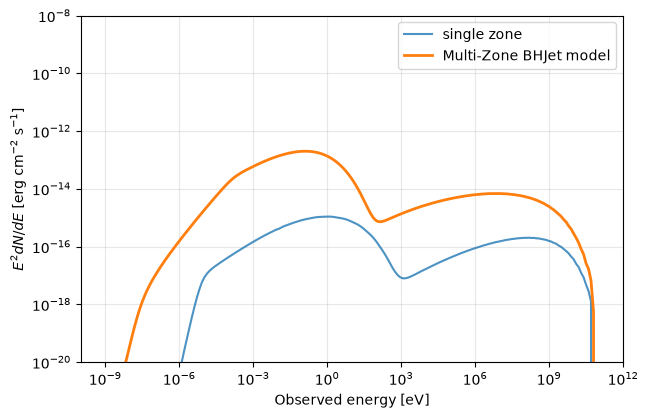

In [45]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(single_zone_energy_eV.to_value(u.Hz, equivalencies=u.spectral()),
          single_zone_sed.to_value(u.erg / (u.cm**2 * u.s)),
          c='k', label='single-zone total', alpha=0.8)
for label, colour in [('synchrotron', 'tab:blue'), ('ssc', 'tab:red')]:
    component_energy, component_sed = single_zone_components[label]
    ax.loglog(component_energy.to_value(u.Hz, equivalencies=u.spectral()),
              component_sed.to_value(u.erg / (u.cm**2 * u.s)),
              c=colour, ls='--', label=f'single-zone {label.upper() if label == 'ssc' else label}')

ax.loglog((energy_eV * u.eV).to_value(u.Hz, equivalencies=u.spectral()),
          multi_zone_sed.to_value(u.erg / (u.cm**2 * u.s)),
          label='Multi-Zone BHJet model', lw=2)
ax.set(xlabel='Observed frequency [Hz]', ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]')
ax.grid(alpha=0.3)
add_observing_band_labels(ax)
ax.legend()
plt.ylim(1e-20, 1e-8)
plt.show()

In [ ]:
# # --- Choose the source and set its physical properties (as provided in the notebook) ---
# SOURCE_NAME = 'GX 339-4'  # Choose 'M87' or 'GX 339-4'
# DISTANCE_KPC = 29400
# REDSHIFT = 0.007465
# VIEWING_ANGLE_DEG = 66.0
# BLACK_HOLE_MASS_SOLAR = 5e8

# data_directory = repository_root / 'tutorials' / 'tutorial_data'
# SOURCE_FILES = {'M87': 'M87_MWL.txt', 'GX 339-4': 'gx3394_MWL.txt'}
# data_file = data_directory / SOURCE_FILES[SOURCE_NAME]